# 04 Supervised Modeling

Trains and compares supervised models on the engineered feature table from `03`, then selects and
evaluates a final model. Here, **full data** means the full customer-level feature table
`data/interim/train_features.parquet` produced from our 1M preprocessed monthly-row subset.

Plan and rationale:

1. Held-out **train/test split** + stratified CV; model comparison and tuning use the **full training split** from the 1M-row-derived feature table. The one exception is full RBF-kernel SVM: with ~66k training customers it would require an enormous kernel matrix under a 12 GB memory budget, so we use a full-split linear SVM and keep RBF SVM as an optional sampled diagnostic.
2. **Model-appropriate preprocessing** (leak-free): impute+scale for linear/SVM/MLP, impute-only for trees, raw for gradient boosting when the implementation handles `NaN` natively.
3. **Baseline comparison** across simple and flexible models so the final choice is not based on one
   algorithm by default.
4. **Hyperparameter tuning** only after the baseline comparison identifies the strongest family, with `n_jobs=1` so cross-validation does not duplicate large design matrices in memory.
5. **Stacking ensemble** as an extension to test whether model families add complementary signal.
6. **Final model**: refit on the full training set, evaluate once on the held-out test set.
7. **Interpretation**: feature importances and linear coefficients connect predictions back to the
   engineered variables.

Classes are imbalanced (~27% default), so we report PR-AUC alongside ROC-AUC: ROC-AUC measures
ranking quality overall, while PR-AUC is more sensitive to performance on the default class.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')  # Apple Accelerate raises spurious matmul FPE warnings

from sklearn.model_selection import train_test_split, StratifiedKFold

INTERIM = Path('../data/interim')
REPORTS = Path('../reports/modeling')
REPORTS.mkdir(parents=True, exist_ok=True)
SEED = 5241

# Memory budget assumption for this notebook run.
# Keep CV/model parallelism at 1 so sklearn does not clone the full feature matrix across workers.
FREE_MEMORY_GB = 24
PARALLEL_JOBS = 2
RUN_FULL_FEATURE_TABLE = True
RUN_OPTIONAL_RBF_SVM_SAMPLE = False
RBF_SVM_SAMPLE_N = 15_000

FEATURES_PATH = INTERIM / 'train_features.parquet'
assert FEATURES_PATH.exists(), 'Run notebooks/03_feature_engineering.ipynb first; this notebook only reads the engineered 1M-row-derived feature table.'
features = pd.read_parquet(FEATURES_PATH)
y = features['target'].astype(int)
X = features.drop(columns='target')

# held-out test set (never used until final evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

# Full feature-table comparison/tuning set. This replaces the earlier 15k downsample.
X_model, y_model = X_train, y_train

# Optional small sample only for RBF-kernel SVM, which is not memory-safe on the full ~66k-customer train split.
if RUN_OPTIONAL_RBF_SVM_SAMPLE:
    X_rbf, _, y_rbf, _ = train_test_split(
        X_train, y_train, train_size=RBF_SVM_SAMPLE_N, stratify=y_train, random_state=SEED
    )
else:
    X_rbf = y_rbf = None

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f'feature table from 1M preprocessed rows {X.shape} | approx memory {features.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'train {X_train.shape} | test {X_test.shape} | model comparison/tuning {X_model.shape}')
print(f'default rate -- train {y_train.mean():.3f}, test {y_test.mean():.3f}')
print(f'memory mode: FREE_MEMORY_GB={FREE_MEMORY_GB}, PARALLEL_JOBS={PARALLEL_JOBS}')

feature table from 1M preprocessed rows (83121, 968) | approx memory 290.7 MB
train (66496, 968) | test (16625, 968) | model comparison/tuning (66496, 968)
default rate -- train 0.270, test 0.270
memory mode: FREE_MEMORY_GB=24, PARALLEL_JOBS=2


## Model-Appropriate Preprocessing

Preprocessing is bundled into each model's `Pipeline` so it is fit **inside** every CV fold (no
leakage). Different model families need different prep:

- **Linear / SVM** (`LogisticRegression`, `LinearSVC`): median impute **+** standardize
- **Bayesian generative baseline** (`GaussianNB`): median impute **+** standardize
- **LDA** (`LinearDiscriminantAnalysis`): median impute **+** standardize; another generative
  classifier
- **Trees** (`DecisionTree`, `RandomForest`): median impute (scaling irrelevant to splits); the forest uses depth/leaf-size limits so the tree objects stay memory-safe
- **Gradient boosting** (`HistGB`, `XGBoost`, `LightGBM`): none — they handle `NaN` natively

Full RBF-kernel `SVC` is intentionally excluded from the full feature-table comparison. A full RBF kernel over ~66k training customers would require a huge pairwise kernel matrix and can exceed a 12 GB working-memory budget. We use `LinearSVC` for the full-split SVM baseline and leave sampled RBF SVM as an optional diagnostic.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

def make_pipe(model, scale=False, impute=True):
    steps = []
    if impute:
        steps.append(('impute', SimpleImputer(strategy='median')))
    if scale:
        steps.append(('scale', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

models = {
    'logreg':  make_pipe(LogisticRegression(max_iter=1000), scale=True),
    'linear_svm': make_pipe(LinearSVC(dual=False, max_iter=5000, random_state=SEED), scale=True),
    'dtree':   make_pipe(DecisionTreeClassifier(max_depth=8, random_state=SEED)),
    'rf':      make_pipe(RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=25, max_features='sqrt', n_jobs=PARALLEL_JOBS, random_state=SEED)),
    'histgb':  HistGradientBoostingClassifier(random_state=SEED),
    'xgb':     xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, n_jobs=PARALLEL_JOBS, eval_metric='logloss', random_state=SEED),
    'lgbm':    lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, n_jobs=PARALLEL_JOBS, verbose=-1, random_state=SEED),
    'gaussian_nb': make_pipe(GaussianNB(), scale=True),                   # Bayesian/generative baseline
    'lda':     make_pipe(LinearDiscriminantAnalysis(), scale=True),       # generative baseline
    'mlp':     make_pipe(MLPClassifier(hidden_layer_sizes=(128, 64), alpha=1e-3,
                                       early_stopping=True, max_iter=200, random_state=SEED), scale=True),
}
print(f'{len(models)} models defined')

10 models defined


## Baseline Comparison

Each feasible model is scored with the same 5-fold CV on the **full training split** from the
1M-row-derived feature table, using ROC-AUC and PR-AUC (average precision). Full RBF-kernel SVM is
excluded for memory safety; the full-split SVM baseline is linear SVM. All CV calls use `n_jobs=1` so a 12 GB free-memory budget is not consumed by
parallel copies of the feature matrix.

In [3]:
from sklearn.model_selection import cross_validate

rows = []
for name, mdl in models.items():
    res = cross_validate(
        mdl, X_model, y_model, cv=cv,
        scoring=['roc_auc', 'average_precision'],
        n_jobs=PARALLEL_JOBS,
    )
    rows.append({
        'model': name,
        'roc_auc': res['test_roc_auc'].mean(),
        'roc_auc_std': res['test_roc_auc'].std(),
        'pr_auc': res['test_average_precision'].mean(),
        'fit_seconds': res['fit_time'].mean(),
    })
    print(f"{name:12s} ROC-AUC {rows[-1]['roc_auc']:.4f} +/- {rows[-1]['roc_auc_std']:.4f} | PR-AUC {rows[-1]['pr_auc']:.4f}")

if RUN_OPTIONAL_RBF_SVM_SAMPLE:
    rbf_pipe = make_pipe(SVC(kernel='rbf'), scale=True)
    res = cross_validate(
        rbf_pipe, X_rbf, y_rbf, cv=cv,
        scoring=['roc_auc', 'average_precision'],
        n_jobs=PARALLEL_JOBS,
    )
    rows.append({
        'model': f'svm_rbf_sample_{len(X_rbf):,}',
        'roc_auc': res['test_roc_auc'].mean(),
        'roc_auc_std': res['test_roc_auc'].std(),
        'pr_auc': res['test_average_precision'].mean(),
        'fit_seconds': res['fit_time'].mean(),
    })

comparison = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
comparison.to_csv(REPORTS / 'model_comparison.csv', index=False)
comparison


logreg       ROC-AUC 0.9550 +/- 0.0016 | PR-AUC 0.8864
linear_svm   ROC-AUC 0.9546 +/- 0.0016 | PR-AUC 0.8851
dtree        ROC-AUC 0.9235 +/- 0.0016 | PR-AUC 0.7993
rf           ROC-AUC 0.9504 +/- 0.0013 | PR-AUC 0.8722
histgb       ROC-AUC 0.9559 +/- 0.0014 | PR-AUC 0.8891
xgb          ROC-AUC 0.9569 +/- 0.0014 | PR-AUC 0.8907
lgbm         ROC-AUC 0.9568 +/- 0.0015 | PR-AUC 0.8904
gaussian_nb  ROC-AUC 0.9051 +/- 0.0015 | PR-AUC 0.6866
lda          ROC-AUC 0.9533 +/- 0.0017 | PR-AUC 0.8802
mlp          ROC-AUC 0.9536 +/- 0.0013 | PR-AUC 0.8820


,model,roc_auc,roc_auc_std,pr_auc,fit_seconds
0,xgb,0.956861,0.001354,0.890666,38.825455
1,lgbm,0.956789,0.001486,0.890363,25.690701
2,histgb,0.955937,0.001390,0.889134,8.345221
3,logreg,0.954957,0.001555,0.886365,5.995550
4,linear_svm,0.954595,0.001572,0.885124,81.819827
5,mlp,0.953577,0.001338,0.882016,10.009627
6,lda,0.953335,0.001738,0.880194,6.953136
7,rf,0.950444,0.001273,0.872184,79.670064
8,dtree,0.923497,0.001609,0.799316,21.585210
9,gaussian_nb,0.905062,0.001547,0.686645,4.372245


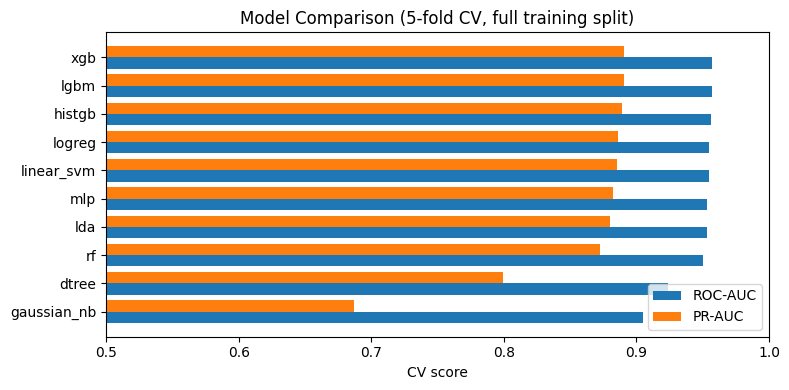

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
order = comparison.sort_values('roc_auc')
x = np.arange(len(order)); w = 0.4
ax.barh(x - w/2, order['roc_auc'], height=w, label='ROC-AUC')
ax.barh(x + w/2, order['pr_auc'], height=w, label='PR-AUC')
ax.set_yticks(x); ax.set_yticklabels(order['model'])
ax.set_xlim(0.5, 1.0); ax.set_xlabel('CV score'); ax.set_title('Model Comparison (5-fold CV, full training split)')
ax.legend(loc='lower right')
fig.tight_layout(); fig.savefig(REPORTS / 'model_comparison.png', dpi=160); plt.show()

## Linear Models: Regularization, Transformations & Dimensionality Reduction

The baseline logistic regression uses default L2 (ridge) regularization. Here we push the *linear*
model specifically (the gradient-boosted models already capture nonlinearity and interactions for
free):

1. tune the penalty -- L1/Lasso, L2/Ridge, elastic-net -- and strength `C`
2. fit an explicit L1/Lasso logistic regression to see how many features can be selected by shrinkage
3. test top-k univariate feature selection inside CV folds
4. test PCA at a 95%-variance cutoff inside CV folds
5. test a Yeo-Johnson transform and top-feature interactions as nonlinear linear-model extensions


best regularized LR: {'model__C': 0.02, 'model__penalty': 'l1'} -> CV ROC-AUC 0.9564
  selects 358/968 features (others shrunk toward 0 if penalty is sparse)
explicit L1 LR: {'model__C': 0.02} -> CV ROC-AUC 0.9564; keeps 359/968
top-50 univariate -> LR CV ROC-AUC 0.9405
top-100 univariate -> LR CV ROC-AUC 0.9441
top-200 univariate -> LR CV ROC-AUC 0.9510
top-400 univariate -> LR CV ROC-AUC 0.9546
PCA: 95% variance retained in 358/968 components


,cv_roc_auc
"regularized LR (l1, C=0.02)",0.9564
L1 LR selected features (C=0.02),0.9564
PCA(95%) -> LR,0.9557
Yeo-Johnson -> LR,0.9550
"logreg (L2, default C)",0.9550
top-400 univariate -> LR,0.9546


,approach,cv_roc_auc,features_used,fit_inside_cv,notes
0,"best regularized LR (l1, C=0.02)",0.9564,358,True,penalty and strength selected by CV; sparse on...
1,L1 LR selected features (C=0.02),0.9564,359,True,embedded feature selection through L1 shrinkage
2,PCA(95%) -> LR,0.9557,358,True,PCA is fit inside each CV fold; component coun...
3,"full LR, all engineered features",0.9550,968,True,baseline linear model on the full engineered t...
4,top-400 univariate -> LR,0.9546,400,True,ANOVA-F feature selector is fit separately ins...
5,top-200 univariate -> LR,0.9510,200,True,ANOVA-F feature selector is fit separately ins...
6,top-100 univariate -> LR,0.9441,100,True,ANOVA-F feature selector is fit separately ins...
7,top-50 univariate -> LR,0.9405,50,True,ANOVA-F feature selector is fit separately ins...


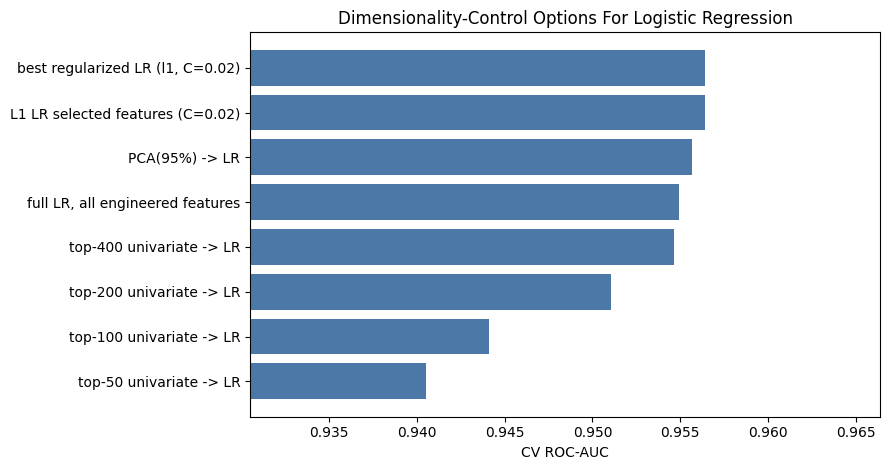


interaction test (top-15 features): 0.9339 alone -> 0.9370 with degree-2 interactions


In [5]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

linear = {'logreg (L2, default C)': float(comparison.set_index('model').loc['logreg', 'roc_auc'])}
dim_rows = [
    {
        'approach': 'full LR, all engineered features',
        'cv_roc_auc': linear['logreg (L2, default C)'],
        'features_used': X_model.shape[1],
        'fit_inside_cv': True,
        'notes': 'baseline linear model on the full engineered table',
    }
]

# (1) tune penalty + strength (saga supports L1/L2/elastic-net)
lr_grid = [
    {'model__penalty': ['l1'], 'model__C': [0.02, 0.05, 0.2, 1.0]},
    {'model__penalty': ['l2'], 'model__C': [0.02, 0.05, 0.2, 1.0]},
    {'model__penalty': ['elasticnet'], 'model__C': [0.2, 1.0], 'model__l1_ratio': [0.3, 0.7]},
]
lr_search = GridSearchCV(make_pipe(LogisticRegression(solver='saga', max_iter=2000), scale=True),
                         lr_grid, scoring='roc_auc',
                         cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=PARALLEL_JOBS).fit(X_model, y_model)
bp = lr_search.best_params_
linear[f"regularized LR ({bp['model__penalty']}, C={bp['model__C']})"] = float(lr_search.best_score_)
n_kept = int((lr_search.best_estimator_.named_steps['model'].coef_ != 0).sum())
print(f"best regularized LR: {bp} -> CV ROC-AUC {lr_search.best_score_:.4f}")
print(f"  selects {n_kept}/{X_model.shape[1]} features (others shrunk toward 0 if penalty is sparse)")
dim_rows.append({
    'approach': f"best regularized LR ({bp['model__penalty']}, C={bp['model__C']})",
    'cv_roc_auc': float(lr_search.best_score_),
    'features_used': n_kept,
    'fit_inside_cv': True,
    'notes': 'penalty and strength selected by CV; sparse only when best penalty is L1/elastic-net',
})

# (2) explicit L1/Lasso feature selection comparison.
l1_search = GridSearchCV(
    make_pipe(LogisticRegression(solver='saga', penalty='l1', max_iter=2000, random_state=SEED), scale=True),
    {'model__C': [0.02, 0.05, 0.2, 1.0]},
    scoring='roc_auc',
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    n_jobs=PARALLEL_JOBS,
).fit(X_model, y_model)
l1_kept = int((l1_search.best_estimator_.named_steps['model'].coef_ != 0).sum())
linear[f"L1 LR selected features (C={l1_search.best_params_['model__C']})"] = float(l1_search.best_score_)
dim_rows.append({
    'approach': f"L1 LR selected features (C={l1_search.best_params_['model__C']})",
    'cv_roc_auc': float(l1_search.best_score_),
    'features_used': l1_kept,
    'fit_inside_cv': True,
    'notes': 'embedded feature selection through L1 shrinkage',
})
print(f"explicit L1 LR: {l1_search.best_params_} -> CV ROC-AUC {l1_search.best_score_:.4f}; keeps {l1_kept}/{X_model.shape[1]}")

# (3) top-k univariate feature selection -> LR. SelectKBest is inside the pipeline, so each fold
# chooses top features using only that fold's training data.
topk_scores = []
for k in [50, 100, 200, 400]:
    k_eff = min(k, X_model.shape[1])
    topk_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('select', SelectKBest(score_func=f_classif, k=k_eff)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000)),
    ])
    auc = float(cross_val_score(topk_pipe, X_model, y_model, cv=cv, scoring='roc_auc', n_jobs=PARALLEL_JOBS).mean())
    topk_scores.append({'k': k_eff, 'cv_roc_auc': auc})
    dim_rows.append({
        'approach': f'top-{k_eff} univariate -> LR',
        'cv_roc_auc': auc,
        'features_used': k_eff,
        'fit_inside_cv': True,
        'notes': 'ANOVA-F feature selector is fit separately inside each CV fold',
    })
    print(f'top-{k_eff} univariate -> LR CV ROC-AUC {auc:.4f}')
best_topk = max(topk_scores, key=lambda row: row['cv_roc_auc'])
linear[f"top-{best_topk['k']} univariate -> LR"] = best_topk['cv_roc_auc']

# (4) PCA at 95%-variance cutoff -> LR. PCA is inside the pipeline during CV.
pca_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler()),
                     ('pca', PCA(n_components=0.95, random_state=SEED)), ('model', LogisticRegression(max_iter=1000))])
linear['PCA(95%) -> LR'] = float(cross_val_score(pca_pipe, X_model, y_model, cv=cv, scoring='roc_auc', n_jobs=PARALLEL_JOBS).mean())
n_pca = pca_pipe.fit(X_model, y_model).named_steps['pca'].n_components_
print(f"PCA: 95% variance retained in {n_pca}/{X_model.shape[1]} components")
dim_rows.append({
    'approach': 'PCA(95%) -> LR',
    'cv_roc_auc': linear['PCA(95%) -> LR'],
    'features_used': n_pca,
    'fit_inside_cv': True,
    'notes': 'PCA is fit inside each CV fold; component count shown from full training-split fit for readability',
})

# (5) Yeo-Johnson power transform -> LR.
yj = Pipeline([('impute', SimpleImputer(strategy='median')),
               ('yeojohnson', PowerTransformer(method='yeo-johnson')),
               ('model', LogisticRegression(max_iter=1000))])
linear['Yeo-Johnson -> LR'] = float(cross_val_score(yj, X_model, y_model, cv=cv, scoring='roc_auc', n_jobs=PARALLEL_JOBS).mean())

linear_df = pd.Series(linear).sort_values(ascending=False).to_frame('cv_roc_auc').round(4)
display(linear_df)

dim_reduction_comparison = pd.DataFrame(dim_rows).sort_values('cv_roc_auc', ascending=False).reset_index(drop=True)
dim_reduction_comparison.to_csv(REPORTS / 'dimensionality_reduction_comparison.csv', index=False)
display(dim_reduction_comparison.round(4))

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = dim_reduction_comparison.sort_values('cv_roc_auc')
ax.barh(plot_df['approach'], plot_df['cv_roc_auc'], color='#4C78A8')
ax.set_xlabel('CV ROC-AUC')
ax.set_title('Dimensionality-Control Options For Logistic Regression')
ax.set_xlim(max(0.5, plot_df['cv_roc_auc'].min() - 0.01), min(1.0, plot_df['cv_roc_auc'].max() + 0.01))
fig.tight_layout(); fig.savefig(REPORTS / 'dimensionality_reduction_comparison.png', dpi=160); plt.show()

# (6) degree-2 interactions among the top-15 features (isolated: same 15, with vs without)
Ximp = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_model), columns=X_model.columns, index=X_model.index)
top15 = Ximp.corrwith(y_model).abs().sort_values(ascending=False).head(15).index.tolist()
base15 = cross_val_score(make_pipe(LogisticRegression(max_iter=1000), scale=True),
                         X_model[top15], y_model, cv=cv, scoring='roc_auc', n_jobs=PARALLEL_JOBS).mean()
inter15 = cross_val_score(Pipeline([('impute', SimpleImputer(strategy='median')),
                                     ('poly', PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                     ('scale', StandardScaler()), ('model', LogisticRegression(max_iter=1000))]),
                          X_model[top15], y_model, cv=cv, scoring='roc_auc', n_jobs=PARALLEL_JOBS).mean()
print(f"\ninteraction test (top-15 features): {base15:.4f} alone -> {inter15:.4f} with degree-2 interactions")


## Neural Network (MLP)

A feed-forward neural net (`MLPClassifier`, two hidden layers 128->64) in the same leak-free
impute->scale pipeline. (A true CNN/LSTM would need the raw per-customer statement
sequences plus a deep-learning framework — out of scope.) The MLP is in the comparison above and the
hold-out leaderboard below.

In [6]:
cmp_auc = comparison.set_index('model')['roc_auc']
print(f"MLP 5-fold CV ROC-AUC: {cmp_auc['mlp']:.4f}  |  best GBDT (lgbm): {cmp_auc['lgbm']:.4f}")
print('As expected, the neural net trails the gradient-boosted trees on this tabular feature table.')
cmp_auc.sort_values(ascending=False).round(4).to_frame('cv_roc_auc')

MLP 5-fold CV ROC-AUC: 0.9536  |  best GBDT (lgbm): 0.9568
As expected, the neural net trails the gradient-boosted trees on this tabular feature table.


,cv_roc_auc
model,
xgb,0.9569
lgbm,0.9568
histgb,0.9559
logreg,0.9550
linear_svm,0.9546
mlp,0.9536
lda,0.9533
rf,0.9504
dtree,0.9235


## Hyperparameter Tuning

Gradient boosting (LightGBM) is the strongest family, so we tune it with `RandomizedSearchCV`
(leak-free: each candidate is CV'd on the full 1M-row-derived training split with serial execution to stay within memory budget).

In [7]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'num_leaves': [15, 31, 63, 127],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [0.0, 1.0, 5.0],
}
search = RandomizedSearchCV(
    lgb.LGBMClassifier(n_jobs=PARALLEL_JOBS, verbose=-1, random_state=SEED),
    param_dist, n_iter=20, scoring='roc_auc',
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED), random_state=SEED, n_jobs=PARALLEL_JOBS,
)
search.fit(X_model, y_model)
print(f'best CV ROC-AUC: {search.best_score_:.4f}')
print('best params:', search.best_params_)
lgbm_tuned = search.best_estimator_

best CV ROC-AUC: 0.9574
best params: {'subsample': 0.7, 'reg_lambda': 0.0, 'num_leaves': 127, 'n_estimators': 400, 'min_child_samples': 100, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


## Stacking Ensemble

We considered a stacked model. We stack a linear model, a random forest, and tuned
LightGBM, with a logistic-regression meta-learner that learns how to weight their predictions
(internal 3-fold to generate out-of-fold base predictions — no leakage).

In [8]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_val_score

stack = StackingClassifier(
    estimators=[
        ('logreg', make_pipe(LogisticRegression(max_iter=1000), scale=True)),
        ('rf', make_pipe(RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=25, max_features='sqrt', n_jobs=PARALLEL_JOBS, random_state=SEED))),
        ('lgbm', lgb.LGBMClassifier(**search.best_params_, n_jobs=PARALLEL_JOBS, verbose=-1, random_state=SEED)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=PARALLEL_JOBS,
)
stack_auc = cross_val_score(stack, X_model, y_model, cv=cv, scoring='roc_auc', n_jobs=1)
print(f'stacking CV ROC-AUC: {stack_auc.mean():.4f} +/- {stack_auc.std():.4f}')

stacking CV ROC-AUC: 0.9566 +/- 0.0014


## Final Model: Refit & Evaluate (AMEX metric)

The selected model is refit on the full training split from `train_features.parquet` and scored on
the internal test split held out at the start of this notebook. That keeps modeling scoped to the
output of preprocessing/EDA/feature engineering; this notebook does **not** read raw Kaggle CSVs.

If an already-built feature-level hold-out file exists, the notebook can also score it as an optional
extra check. That file is not required for training.

We report ROC-AUC, PR-AUC, and the **official AMEX competition metric** `M = 0.5·(G + D)` --
normalized weighted Gini `G` plus default capture in the top 4% `D` (negatives weighted 20x), the
same rank-ordering metric the competition used.

selected final model: lgbm_tuned (comparison CV ROC-AUC 0.9574)


,roc_auc,pr_auc,amex_M,gini_G,capture_D@4pct
set,,,,,
internal test split,0.9551,0.8908,0.7716,0.9102,0.6330
optional feature-level hold-out,0.9595,0.8970,0.7826,0.9190,0.6462


confusion matrix on internal test (threshold 0.5):
[[11255   888]
 [  871  3611]]
              precision    recall  f1-score   support

           0      0.928     0.927     0.928     12143
           1      0.803     0.806     0.804      4482

    accuracy                          0.894     16625
   macro avg      0.865     0.866     0.866     16625
weighted avg      0.894     0.894     0.894     16625



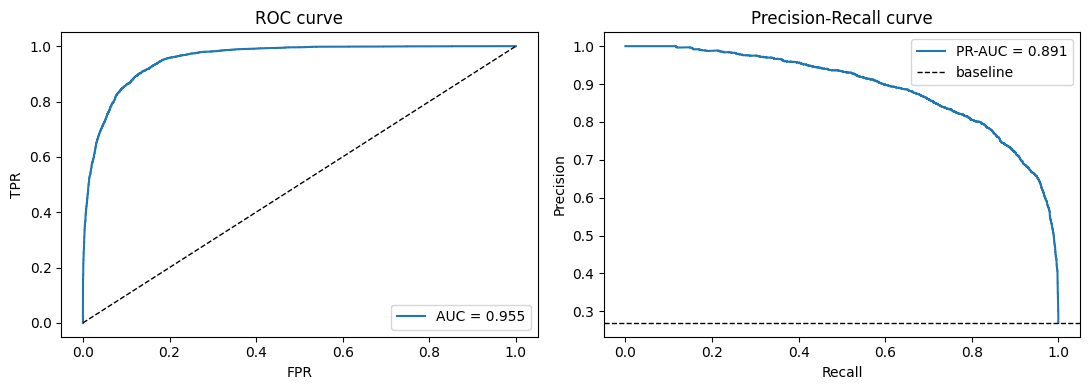

In [9]:
import numpy as np
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

def amex_metric(y_true, y_pred):
    """Official AMEX metric (Kaggle 'inversion'): mean of normalized weighted Gini and default
    capture at the top 4%; negatives weighted 20x. Returns (M, gini_norm, top4_capture)."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    lab = np.transpose(np.array([y_true, y_pred])); lab = lab[lab[:, 1].argsort()[::-1]]
    w = np.where(lab[:, 0] == 0, 20, 1)
    cut = lab[np.cumsum(w) <= int(0.04 * np.sum(w))]
    top4 = cut[:, 0].sum() / lab[:, 0].sum()
    gini = [0.0, 0.0]
    for i in [1, 0]:
        lab = np.transpose(np.array([y_true, y_pred])); lab = lab[lab[:, i].argsort()[::-1]]
        w = np.where(lab[:, 0] == 0, 20, 1)
        rand = np.cumsum(w / w.sum())
        lorentz = np.cumsum(lab[:, 0] * w) / np.sum(lab[:, 0] * w)
        gini[i] = np.sum((lorentz - rand) * w)
    return 0.5 * (gini[1] / gini[0] + top4), gini[1] / gini[0], top4

candidates = {'lgbm_tuned': search.best_score_, 'stacking': stack_auc.mean()}
best_name = max(candidates, key=candidates.get)
final_model = lgbm_tuned if best_name == 'lgbm_tuned' else stack
final_model.fit(X_train, y_train)
print(f'selected final model: {best_name} (comparison CV ROC-AUC {candidates[best_name]:.4f})')

def model_scores(model, X_eval):
    # Metrics used here need a continuous ranking score, not necessarily calibrated probabilities.
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_eval)
    return model.predict(X_eval)

def evaluate(name, model, Xe, ye):
    p = model_scores(model, Xe)
    M, G, D = amex_metric(ye, p)
    return {'set': name, 'roc_auc': roc_auc_score(ye, p), 'pr_auc': average_precision_score(ye, p),
            'amex_M': M, 'gini_G': G, 'capture_D@4pct': D}, p

def load_optional_holdout(path, expected_columns):
    """Load holdout only if its feature schema matches the current engineered training table."""
    if not path.exists():
        print('NOTE: optional hold-out not found; continuing with the internal test split only.')
        return None
    ho = pd.read_parquet(path)
    Xho = ho.drop(columns='target')
    yho = ho['target'].astype(int)
    expected = list(expected_columns)
    actual = list(Xho.columns)
    if actual != expected:
        missing = sorted(set(expected) - set(actual))[:8]
        extra = sorted(set(actual) - set(expected))[:8]
        print('NOTE: optional hold-out feature schema does not match the current train_features.parquet; skipping it.')
        print(f'  missing expected columns, first few: {missing}')
        print(f'  extra stale columns, first few: {extra}')
        return None
    return Xho, yho

eval_rows = []
res_int, proba = evaluate('internal test split', final_model, X_test, y_test)
eval_rows.append(res_int)

HOLDOUT = INTERIM / 'test_features_holdout.parquet'
holdout_data = load_optional_holdout(HOLDOUT, X_train.columns)
if holdout_data is not None:
    Xho, yho = holdout_data
    res_ext, _ = evaluate('optional feature-level hold-out', final_model, Xho, yho)
    eval_rows.append(res_ext)

display(pd.DataFrame(eval_rows).set_index('set').round(4))

pred = (proba >= 0.5).astype(int)
print('confusion matrix on internal test (threshold 0.5):'); print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, label=f"AUC = {res_int['roc_auc']:.3f}"); axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC curve'); axes[0].legend()
prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, label=f"PR-AUC = {res_int['pr_auc']:.3f}"); axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label='baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall curve'); axes[1].legend()
fig.tight_layout(); fig.savefig(REPORTS / 'final_model_curves.png', dpi=160); plt.show()

In [10]:
# Optional: how the main model families rank on an already-built feature-level hold-out
# This cell is optional. It depends on helpers defined in the Final Model cell above.
if 'load_optional_holdout' not in globals() or 'model_scores' not in globals() or 'amex_metric' not in globals():
    print('Skipping optional hold-out leaderboard; rerun the Final Model evaluation cell above first if you want this optional check.')
elif 'holdout_data' not in globals():
    holdout_data = load_optional_holdout(INTERIM / 'test_features_holdout.parquet', X_train.columns)

if 'holdout_data' in globals() and holdout_data is None:
    print('Skipping optional hold-out leaderboard; internal test split results above are the valid evaluation for this run.')
elif 'holdout_data' in globals():
    Xho, yho = holdout_data
    contenders = {'regularized LR': lr_search.best_estimator_, 'random forest': models['rf'],
                  'xgboost': models['xgb'], 'lgbm (tuned)': lgbm_tuned, 'mlp (neural net)': models['mlp'], 'linear svm': models['linear_svm']}
    board = []
    for name, mdl in contenders.items():
        mdl.fit(X_train, y_train)
        p = model_scores(mdl, Xho)
        M, G, D = amex_metric(yho, p)
        board.append({'model': name, 'roc_auc': roc_auc_score(yho, p),
                      'amex_M': M, 'gini_G': G, 'capture_D@4pct': D})
    board = pd.DataFrame(board).sort_values('amex_M', ascending=False).reset_index(drop=True)
    board.to_csv(REPORTS / 'holdout_amex_leaderboard.csv', index=False)
    display(board.round(4))

,model,roc_auc,amex_M,gini_G,capture_D@4pct
0,lgbm (tuned),0.9595,0.7826,0.9190,0.6462
1,xgboost,0.9590,0.7801,0.9181,0.6421
2,regularized LR,0.9583,0.7775,0.9165,0.6384
3,mlp (neural net),0.9559,0.7681,0.9118,0.6243
4,linear svm,0.9485,0.7537,0.8969,0.6105
5,random forest,0.9527,0.7524,0.9055,0.5993


## Interpretation

Which features drive predictions? We show LightGBM's gain-based importances (refit on full train)
and the largest standardized logistic-regression coefficients.

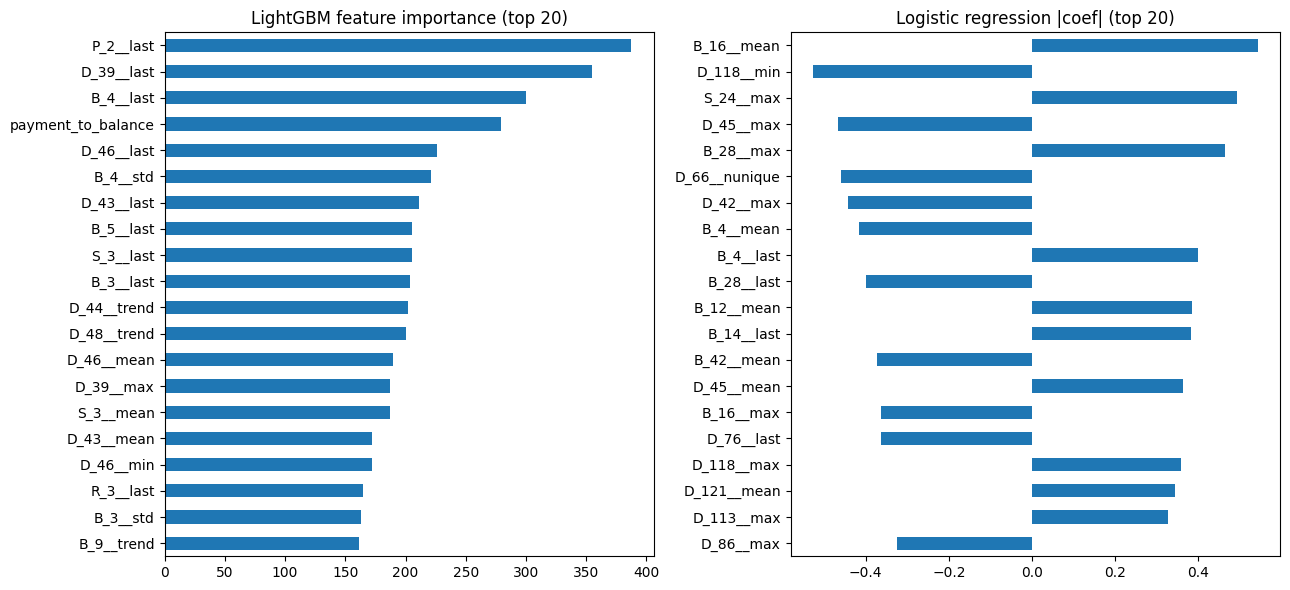

,lgbm_importance
P_2__last,387
D_39__last,355
B_4__last,300
payment_to_balance,279
D_46__last,226
B_4__std,221
D_43__last,211
B_5__last,205
S_3__last,205
B_3__last,204


In [11]:
lgbm_full = lgb.LGBMClassifier(**search.best_params_, n_jobs=PARALLEL_JOBS, verbose=-1, random_state=SEED).fit(X_train, y_train)
imp = pd.Series(lgbm_full.feature_importances_, index=X_train.columns).sort_values(ascending=False)

logreg_full = make_pipe(LogisticRegression(max_iter=1000), scale=True).fit(X_train, y_train)
coef = pd.Series(logreg_full.named_steps['model'].coef_[0], index=X_train.columns)
coef_top = coef.reindex(coef.abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
imp.head(20)[::-1].plot.barh(ax=axes[0]); axes[0].set_title('LightGBM feature importance (top 20)')
coef_top.head(20)[::-1].plot.barh(ax=axes[1]); axes[1].set_title('Logistic regression |coef| (top 20)')
fig.tight_layout(); fig.savefig(REPORTS / 'feature_importance.png', dpi=160); plt.show()

imp.head(20).to_frame('lgbm_importance')

## Model Artifact Export For Interpretability

The interpretability notebook, `06_interpretability.ipynb`, needs fitted model objects rather than only summary
scores. This cell refits a representative model from each family on the same training split used for
final evaluation and saves those fitted objects locally under `models/supervised/`.

The saved `.joblib` files are intentionally local artifacts: they can be regenerated by rerunning this
notebook and should not be committed because they are larger binary outputs.

In [12]:
from sklearn.base import clone
import joblib

MODEL_DIR = Path('../models/supervised')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Keep these names stable: 06_interpretability.ipynb loads them by name.
artifact_specs = [
    ('regularized_lr', lr_search.best_estimator_, 'linear', 'standardized coefficients'),
    ('logreg_l2', logreg_full, 'linear', 'standardized coefficients'),
    ('linear_svm', clone(models['linear_svm']), 'svm', 'linear margin coefficients + permutation'),
    ('decision_tree', clone(models['dtree']), 'single_tree', 'tree structure + impurity importance'),
    ('random_forest', clone(models['rf']), 'tree_ensemble', 'mean impurity importance'),
    ('histgb', clone(models['histgb']), 'tree_ensemble', 'permutation importance'),
    ('xgboost', clone(models['xgb']), 'tree_ensemble', 'gain/split importance'),
    ('lgbm_tuned', lgb.LGBMClassifier(**search.best_params_, n_jobs=PARALLEL_JOBS, verbose=-1, random_state=SEED), 'tree_ensemble', 'split importance'),
    ('gaussian_nb', clone(models['gaussian_nb']), 'bayesian', 'class-conditional mean differences'),
    ('lda', clone(models['lda']), 'linear_generative', 'linear coefficients'),
    ('mlp', clone(models['mlp']), 'neural_net', 'first-layer weights + permutation'),
]

artifact_rows = []
trained_artifacts = {}
for name, estimator, family, interpretation in artifact_specs:
    print(f'fitting/saving {name}...')
    if name in {'regularized_lr', 'logreg_l2'}:
        fitted = estimator
    else:
        fitted = estimator.fit(X_train, y_train)
    path = MODEL_DIR / f'{name}.joblib'
    joblib.dump(fitted, path, compress=3)
    trained_artifacts[name] = fitted
    artifact_rows.append({
        'model': name,
        'family': family,
        'artifact_path': str(Path('models/supervised') / path.name),
        'interpretation': interpretation,
        'train_rows': len(X_train),
        'features': X_train.shape[1],
    })

# Save the selected final model separately, even if it duplicates lgbm_tuned or stacking.
final_path = MODEL_DIR / 'final_model.joblib'
joblib.dump(final_model, final_path, compress=3)
artifact_rows.append({
    'model': 'final_model',
    'family': best_name,
    'artifact_path': str(Path('models/supervised') / final_path.name),
    'interpretation': 'selected final estimator from this notebook',
    'train_rows': len(X_train),
    'features': X_train.shape[1],
})

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(MODEL_DIR / 'model_artifact_manifest.csv', index=False)

feature_schema = {
    'features_path': str(FEATURES_PATH),
    'target_column': 'target',
    'feature_columns': X_train.columns.tolist(),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'seed': int(SEED),
    'selected_final_model': best_name,
}
(MODEL_DIR / 'feature_schema.json').write_text(json.dumps(feature_schema, indent=2))

print(f'saved {len(artifact_manifest)} model artifacts to {MODEL_DIR}')
display(artifact_manifest)


fitting/saving regularized_lr...
fitting/saving logreg_l2...
fitting/saving linear_svm...
fitting/saving decision_tree...
fitting/saving random_forest...
fitting/saving histgb...
fitting/saving xgboost...
fitting/saving lgbm_tuned...
fitting/saving gaussian_nb...
fitting/saving lda...
fitting/saving mlp...
saved 12 model artifacts to ../models/supervised


,model,family,artifact_path,interpretation,train_rows,features
0,regularized_lr,linear,models/supervised/regularized_lr.joblib,standardized coefficients,66496,968
1,logreg_l2,linear,models/supervised/logreg_l2.joblib,standardized coefficients,66496,968
2,linear_svm,svm,models/supervised/linear_svm.joblib,linear margin coefficients + permutation,66496,968
3,decision_tree,single_tree,models/supervised/decision_tree.joblib,tree structure + impurity importance,66496,968
4,random_forest,tree_ensemble,models/supervised/random_forest.joblib,mean impurity importance,66496,968
5,histgb,tree_ensemble,models/supervised/histgb.joblib,permutation importance,66496,968
6,xgboost,tree_ensemble,models/supervised/xgboost.joblib,gain/split importance,66496,968
7,lgbm_tuned,tree_ensemble,models/supervised/lgbm_tuned.joblib,split importance,66496,968
8,gaussian_nb,bayesian,models/supervised/gaussian_nb.joblib,class-conditional mean differences,66496,968
9,lda,linear_generative,models/supervised/lda.joblib,linear coefficients,66496,968


In [13]:
# Export a rendered copy of this finished notebook.
# This works whether Jupyter's current directory is the project root or notebooks/.
from pathlib import Path
import subprocess
import sys

if Path('04_supervised_modeling.ipynb').exists():
    notebook_path = Path('04_supervised_modeling.ipynb')
    output_dir = Path('../reports/modeling')
elif Path('notebooks/04_supervised_modeling.ipynb').exists():
    notebook_path = Path('notebooks/04_supervised_modeling.ipynb')
    output_dir = Path('reports/modeling')
else:
    raise FileNotFoundError('Could not find 04_supervised_modeling.ipynb from the current working directory.')

output_dir.mkdir(parents=True, exist_ok=True)
output_name = '04_supervised_modeling_finished'

subprocess.run(
    [
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html',
        '--output', output_name,
        '--output-dir', str(output_dir),
        str(notebook_path),
    ],
    check=True,
)

print(f'saved rendered notebook to {output_dir / (output_name + ".html")}')


[NbConvertApp] Converting notebook 04_supervised_modeling.ipynb to html


saved rendered notebook to ../reports/modeling/04_supervised_modeling_finished.html


[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 648239 bytes to ../reports/modeling/04_supervised_modeling_finished.html
